Этот проект не раотает, т.к. не стаивться тензерфлоу

В этом файле будем основываться на проект https://www.geeksforgeeks.org/multivariate-time-series-forecasting-with-lstms-in-keras/?__ya_mt_enable_static_translations=1

И на старый проект p1 с нира

проект с реконвертациией минимакс нормализации LSTM от сюда --> https://www.geeksforgeeks.org/time-series-forecasting-using-pytorch/

интерсно, что в этом проекте применяется минимакснормализация, но потом значения предсказываются ( либо конвертируются) в нормальную цену 

In [27]:
import datetime
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import KernelPCA
import numpy as np
import pandas as pd
import math
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
tf.random.set_seed(99)


In [28]:
tf.random.set_seed(99)
tf.compat.v1.enable_eager_execution() #используете Eager execution (режим немедленного выполнения
from sklearn.metrics import mean_squared_error
import csv

with open('UREZ.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['MSE', 'MAE', 'R2'])

# ПРОСТО УДАЛИМ ВСЕМ ПАРАМЕТРЫ КРОМЕ ОБЫЧНОЙ СВЕЧИ удалим: 'val','trades','trades_b','trades_s','val_b','val_s','vol_b','vol_s',


In [29]:

# Здесь НАЧНЁМ подготваливать свои данные
dataFrame = pd.read_csv('file_for_input/all_hour/SBER_tradestats_test_hour.csv ')
dataFrame['tradedate'] = dataFrame['tradedate'] + '-' + dataFrame['tradetime_hour'].astype(str)
dataFrame = dataFrame.drop('tradetime_hour', axis=1)
dataFrame = dataFrame.drop('val', axis=1)
dataFrame = dataFrame.drop('trades', axis=1)
dataFrame = dataFrame.drop('trades_b', axis=1)
dataFrame = dataFrame.drop('trades_s', axis=1)
dataFrame = dataFrame.drop('val_b', axis=1)
dataFrame = dataFrame.drop('val_s', axis=1)
dataFrame = dataFrame.drop('vol_b', axis=1)
dataFrame = dataFrame.drop('vol_s', axis=1)



dataFrame = dataFrame.rename(columns={'tradedate': 'Date'})
dataFrame = dataFrame.rename(columns={'pr_close_hour': 'Close'})
dataFrame = dataFrame.rename(columns={'pr_open_hour': 'Open'})
print(dataFrame.columns)
print(dataFrame.head(n=2))
print("KONEC -----------------------------------")

Index(['Date', 'vol', 'Open', 'Close', 'pr_high_hour', 'pr_low_hour'], dtype='object')
            Date       vol    Open   Close  pr_high_hour  pr_low_hour
0  2020-01-03-10  393181.0  255.97  256.22        256.97       255.83
1  2020-01-03-11  404569.0  256.15  256.68        256.90       255.52
KONEC -----------------------------------


In [30]:
#Data preprocessing
imputer = SimpleImputer(missing_values=np.nan) # Handling missing values
dataFrame.drop(columns=['Date'], inplace=True)
dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
dataFrame = dataFrame.reset_index(drop=True)



In [31]:
# Single step dataset preparation
def singleStepSampler(df, window):
	xRes = []
	yRes = []
	for i in range(0, len(df) - window):
		res = []
		for j in range(0, window):
			r = []
			for col in df.columns:
				r.append(df[col][i + j])
			res.append(r)
		xRes.append(res)
		yRes.append(df[['Open', 'Close']].iloc[i + window].values)
	return np.array(xRes), np.array(yRes)

In [32]:
# Dataset splitting
SPLIT = 0.85
(xVal, yVal) = singleStepSampler(dataFrame, 20) # было (xVal, yVal) = singleStepSampler(df_scaled, 20)
print("Кол-во данных после сплитинга ",len(xVal),len(yVal))


X_final_test = xVal[int(SPLIT * len(xVal)):]
y_final_test = yVal[int(SPLIT * len(yVal)):]
xVal = xVal[:int(SPLIT * len(xVal))]
yVal = yVal[:int(SPLIT * len(yVal))]
print("длина X_final_test,y_final_test ",len(X_final_test),len(y_final_test))
print("Кол-во данных после X_final_test ",len(xVal),len(yVal))


X_train = xVal[:int(SPLIT * len(xVal))]
y_train = yVal[:int(SPLIT * len(yVal))]
X_test = xVal[int(SPLIT * len(xVal)):]
y_test = yVal[int(SPLIT * len(yVal)):]
print("(обычное обучение)Кол-во данных  X_train, y_train ",len(X_train),len(y_train))
print("(обычное обучение)Кол-во данных  X_test, y_test ",len(X_test),len(y_test))

Кол-во данных после сплитинга  8505 8505
длина X_final_test,y_final_test  1276 1276
Кол-во данных после X_final_test  7229 7229
(обычное обучение)Кол-во данных  X_train, y_train  6144 6144
(обычное обучение)Кол-во данных  X_test, y_test  1085 1085


Сама модель

In [33]:
multivariate_lstm = keras.Sequential()
multivariate_lstm.add(keras.layers.LSTM(20, input_shape=(X_train.shape[1], X_train.shape[2])))
multivariate_lstm.add(keras.layers.Dropout(0.2))
multivariate_lstm.add(keras.layers.Dense(2, activation='linear'))
multivariate_lstm.compile(loss='mae', metrics=['mse'], optimizer='adam') # Было: metrics=['mae']
multivariate_lstm.summary()

C:\TRADE_LapTop\KanNootebook\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 20)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122 (8.29 KB)

 Trainable params: 2,122 (8.29 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = multivariate_lstm.fit(X_train, y_train, epochs=50)

# Оценка исходной точности модели
y_pred = multivariate_lstm.predict(X_test)
baseline_mse = mean_squared_error(y_test, y_pred)
print(f"Baseline MSE: {baseline_mse}")

Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 236.6431 - mse: 61283.4844
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 235.7783 - mse: 60875.5273
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 234.9189 - mse: 60471.0000
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 234.0702 - mse: 60071.0938
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 233.1712 - mse: 59650.2617
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 232.3225 - mse: 59256.9297
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 231.4802 - mse: 58866.7031
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 230.5899 - mse: 58455.7383
Epoch 9/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 229.7511 - mse: 58069.0039
Epoch 10/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 228.8874 - mse: 57676.4023
Epoch 11/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 228.0215 - mse: 57276.6172
Epoch 12/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 

In [36]:
# Model Evaluation  МЕТРИКИ МОДЕЛИ
def eval(model):
	return {
		'MSE': sklearn.metrics.mean_squared_error(d[f'Actual_{model.split("_")[1]}'].to_numpy(), d[model].to_numpy()),
		'MAE': sklearn.metrics.mean_absolute_error(d[f'Actual_{model.split("_")[1]}'].to_numpy(), d[model].to_numpy()),
		'R2': sklearn.metrics.r2_score(d[f'Actual_{model.split("_")[1]}'].to_numpy(), d[model].to_numpy())
	}

result = dict()

for item in ['Predicted_Close']:
	result[item] = eval(item)

print(result)

{'Predicted_Close': {'MSE': np.float64(7880.605720286974), 'MAE': np.float64(84.5535770966842), 'R2': -9.776184629445465}}


In [37]:
# Начинаем работу с X_final_test Y_final_test

y_pred_final_test = multivariate_lstm.predict(X_final_test) # Предсказываем значения
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

#  Добавляем метрики на основе фактических значений y_final_test и предсказанных значений y_pred_final_test:
mse_final_test = mean_squared_error(y_final_test, y_pred_final_test)
mae_final_test = mean_absolute_error(y_final_test, y_pred_final_test)
r2_final_test = r2_score(y_final_test, y_pred_final_test)

print(f"MSE на тестовой выборке: {mse_final_test:.10f}")
print(f"MAE на тестовой выборке: {mae_final_test:.10f}")
print(f"R2 на тестовой выборке: {r2_final_test:.10f}")


# оздайте DataFrame для хранения фактических и предсказанных значений:

d_final_test = pd.DataFrame({
	'Actual_Open': y_final_test[:, 0],
	'Actual_Close': y_final_test[:, 1],
	'Predicted_Open': y_pred_final_test[:, 0],
	'Predicted_Close': y_pred_final_test[:, 1]
})

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
MSE на тестовой выборке: 43014.8080584992
MAE на тестовой выборке: 206.9709776390
R2 на тестовой выборке: -241.0243360422


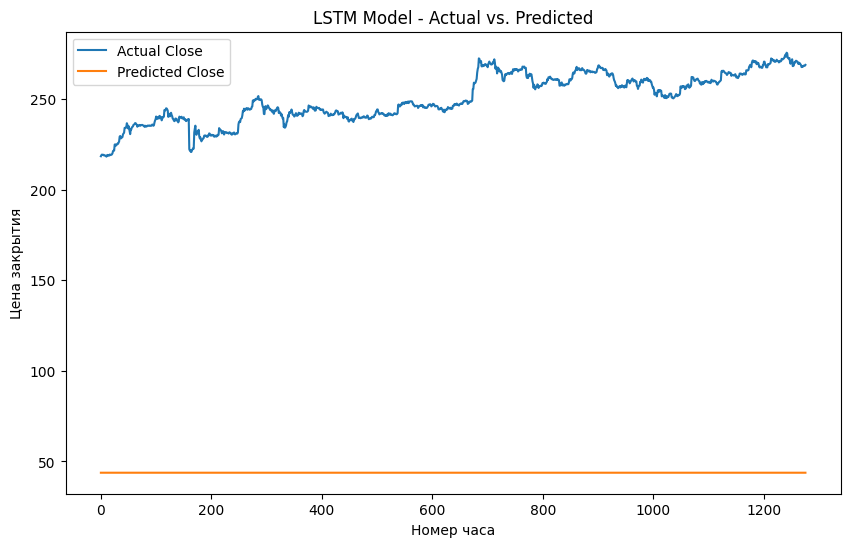

In [38]:
# Рисуем график фактических и предсказанных значений:
plt.figure(figsize=(10, 6))

plt.plot(d_final_test['Actual_Close'], label='Actual Close')
plt.plot(d_final_test['Predicted_Close'], label='Predicted Close')

plt.title('LSTM Model - Actual vs. Predicted')
plt.xlabel('Номер часа')
plt.ylabel('Цена закрытия')
plt.legend()
plt.show()